In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

ModuleNotFoundError: No module named 'yellowbrick'

Preparing data

In [ ]:
X,y,c = make_blobs(500, cluster_std=0.8, centers=4, n_features=2, return_centers=True)

In [ ]:
df_blobs = pd.DataFrame({
    'x1': X[:,0],
    'x2': X[:,1],
    'y': y,
})

In [ ]:
df_centers = pd.DataFrame({
    'c1': c[:,0],
    'c2': c[:,1],
})

Data visualization

In [ ]:
def plot_2d_clusters(x,y,ax):
    y_uniques = pd.Series(y).unique()
    
    for i in y_uniques:
        x[y==i].plot(
            title=f'{len(y_uniques)} Clusters',
            kind='scatter',
            x='x1',
            y='x2',
            marker= f'${i}$',
            ax=ax
        )

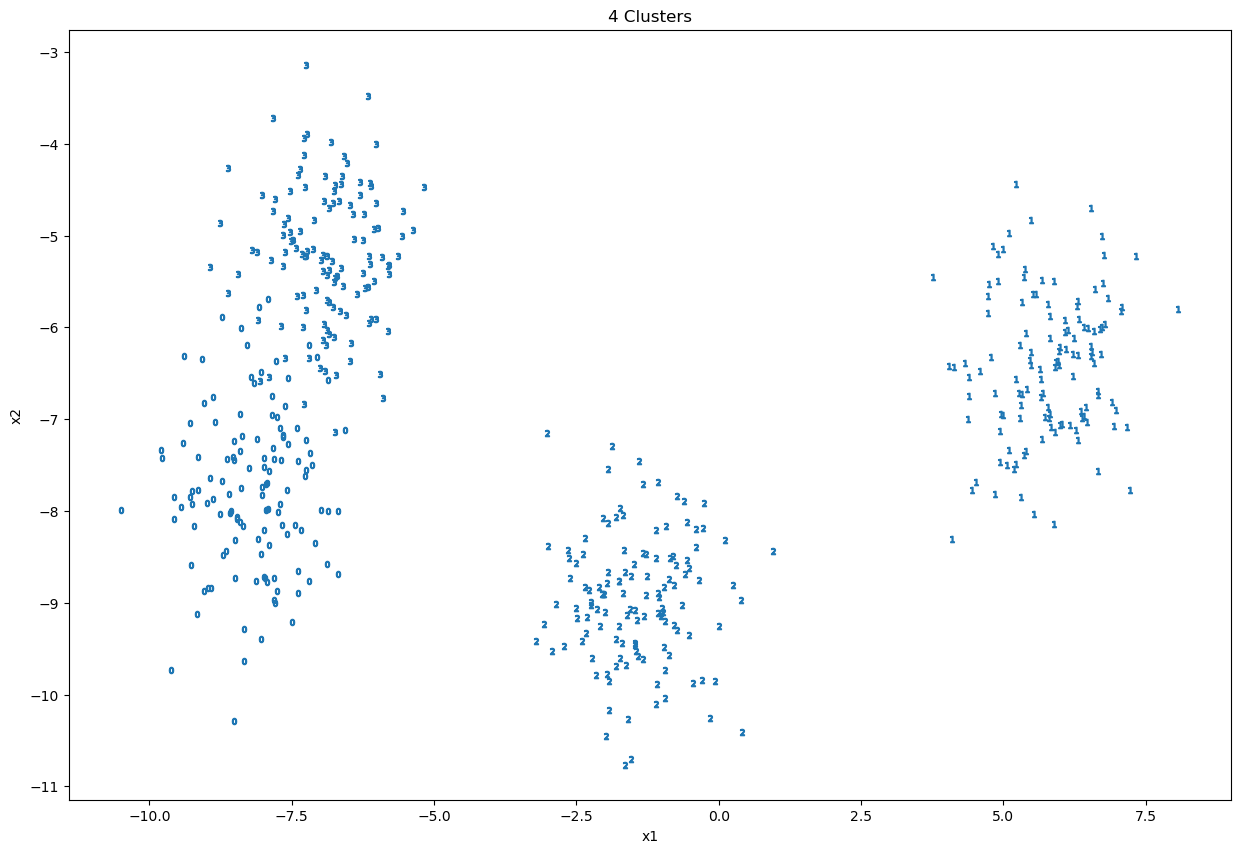

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(15,10))
x, y = df_blobs[['x1','x2']], df_blobs['y']
plot_2d_clusters(x,y,ax)

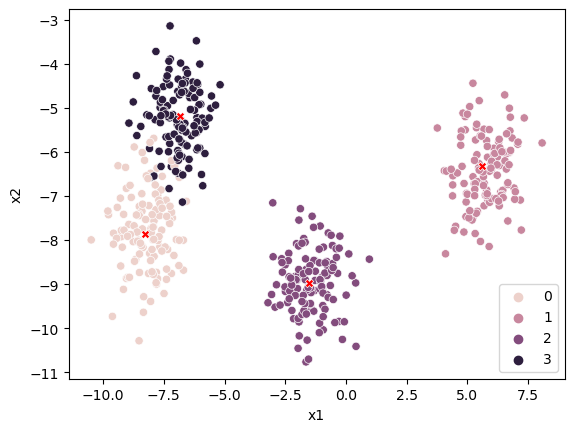

In [ ]:
sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='y',marker='o')
sns.scatterplot(data=df_centers,x='c1',y='c2',marker='X',color="red")
plt.show()

Applying kmeans

In [ ]:
k_means = KMeans(n_clusters=4)
df_blobs['y_pred'] = k_means.fit_predict(X)
y_pred_centers = k_means.cluster_centers_

df_y_pred_centers = pd.DataFrame({
    'x1': y_pred_centers[:,0],
    'x2': y_pred_centers[:,1]
})

/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: xlabel='x1', ylabel='x2'>

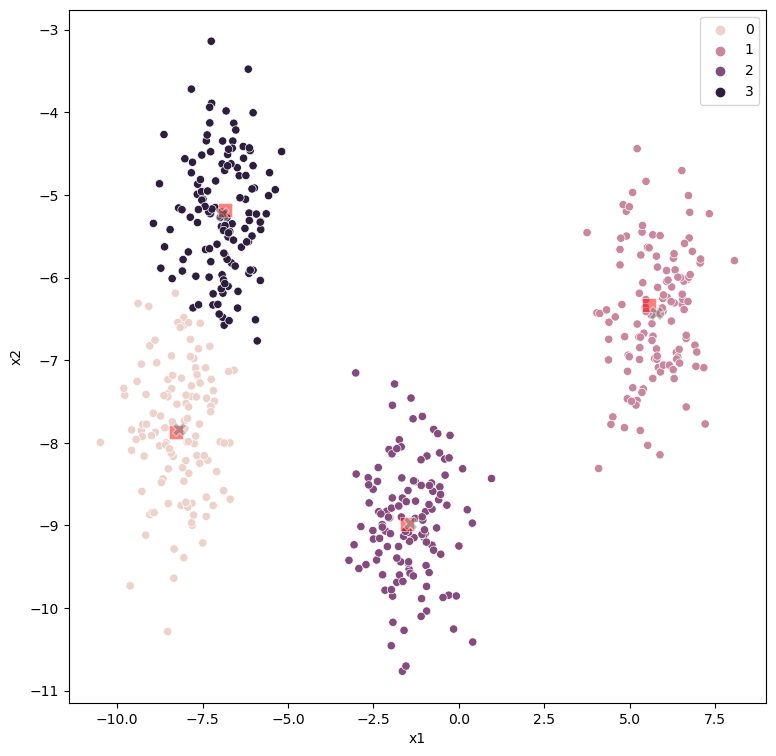

In [ ]:
fig = plt.figure(figsize=(9,9))

sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='y_pred')
sns.scatterplot(data=df_centers,x='c1',y='c2',marker='s',color='red',alpha=0.5,s=100)
sns.scatterplot(data=df_y_pred_centers,x='x1',y='x2',marker='X',color='grey',alpha=0.5,s=100)

plt.show()

In [ ]:
def vis_cluster(k):
    kmeans = KMeans(n_clusters=k)
    df_blobs['cluster'] = kmeans.fit_predict(X)
    df_k_means_center = pd.DataFrame({
        'x1': kmeans.cluster_centers_[:,0],
        'x2': kmeans.cluster_centers_[:,1]
    })
    fig = plt.figure(figsize=(9,9))
    sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='cluster')
    sns.scatterplot(data=df_centers,x='c1',y='c2',marker='s',color='red',alpha=0.5,s=100)
    sns.scatterplot(data=df_k_means_center,x='x1',y='x2',marker='X',color='grey',alpha=0.5,s=100)
    plt.show()

3


/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


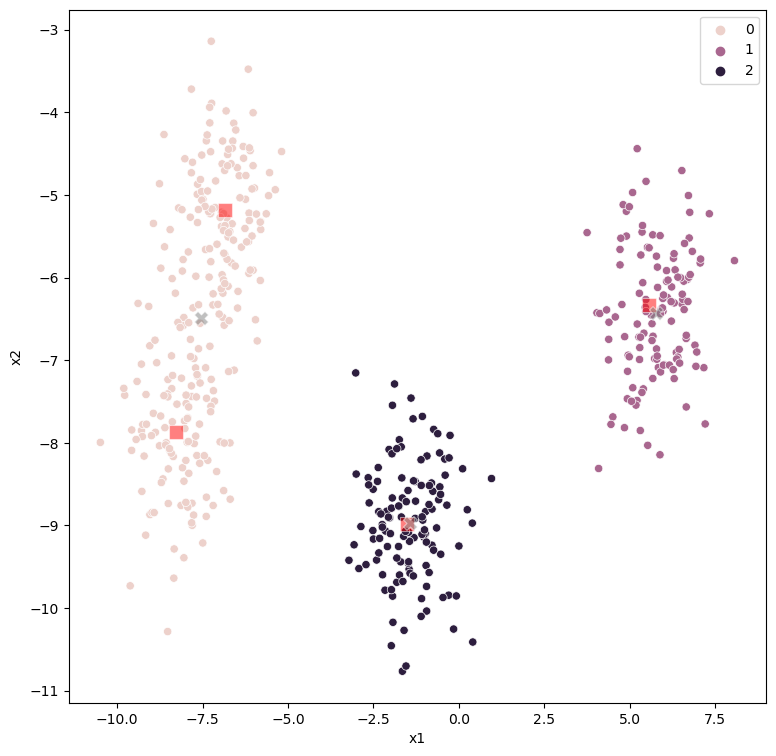

4


/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


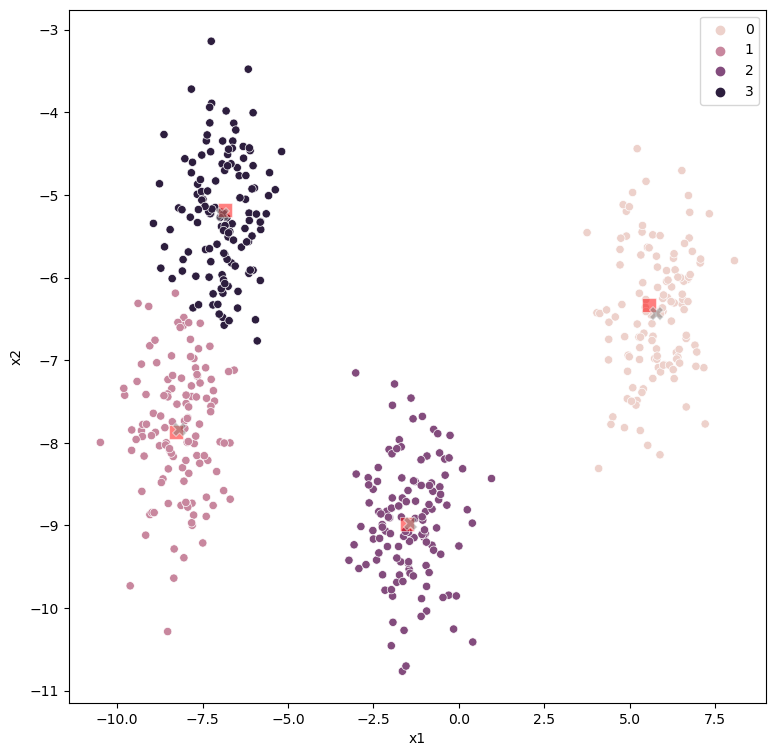

5


/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


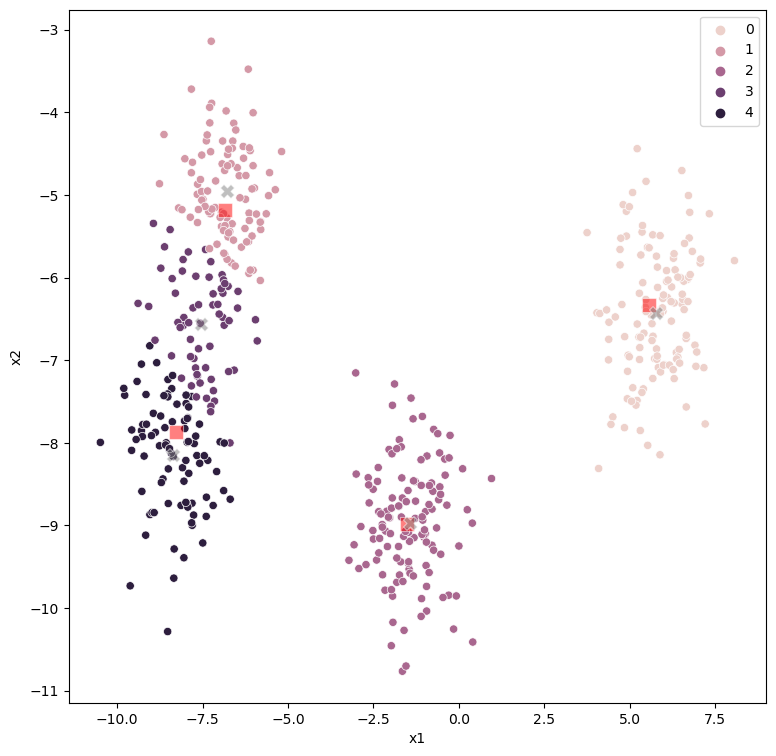

6


/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


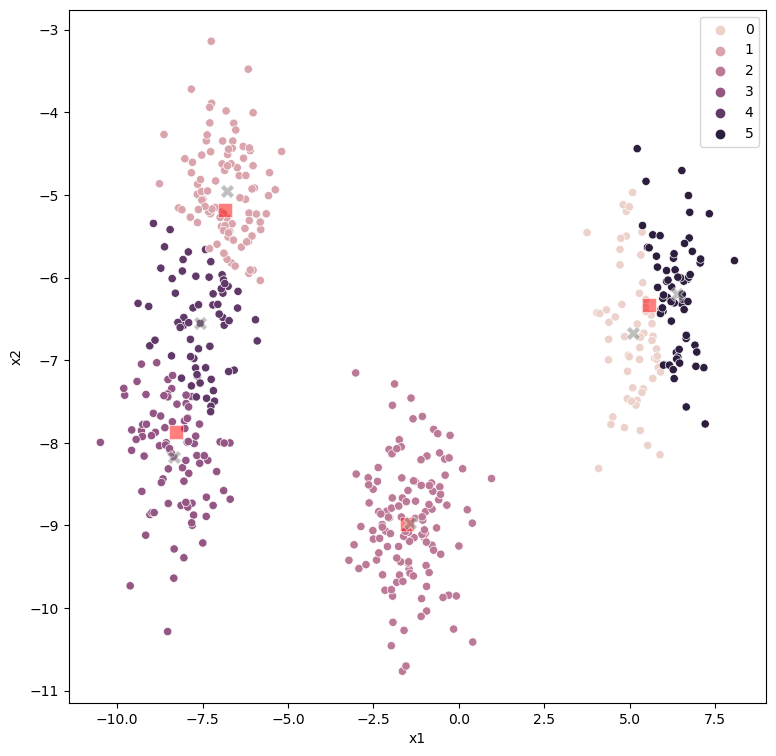

In [ ]:
for i in range(3,7):
    print(i)
    vis_cluster(i)

Finding the best value for K

/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anacond

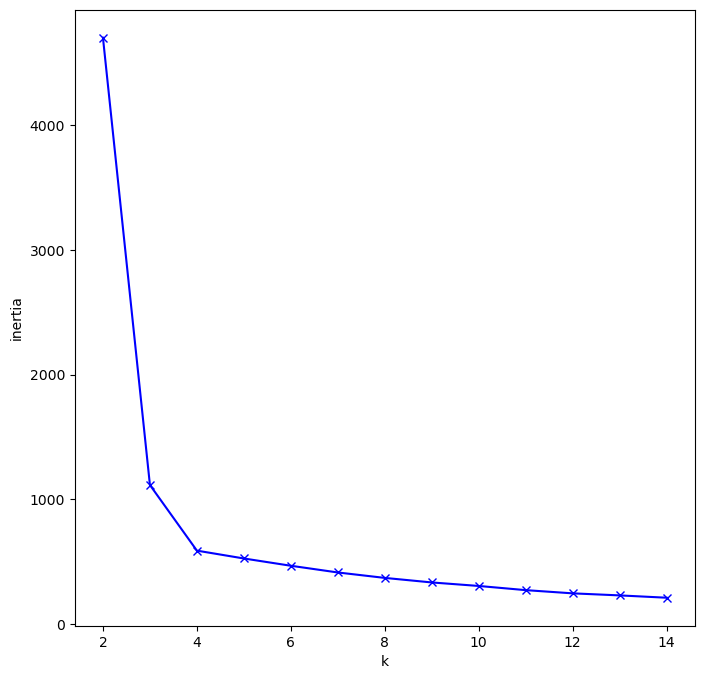

In [ ]:
sum_of_squared_distances = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(X)
    sum_of_squared_distances.append(km.inertia_)
    
plt.figure(figsize=(8,8))
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/ubuntu/anacond

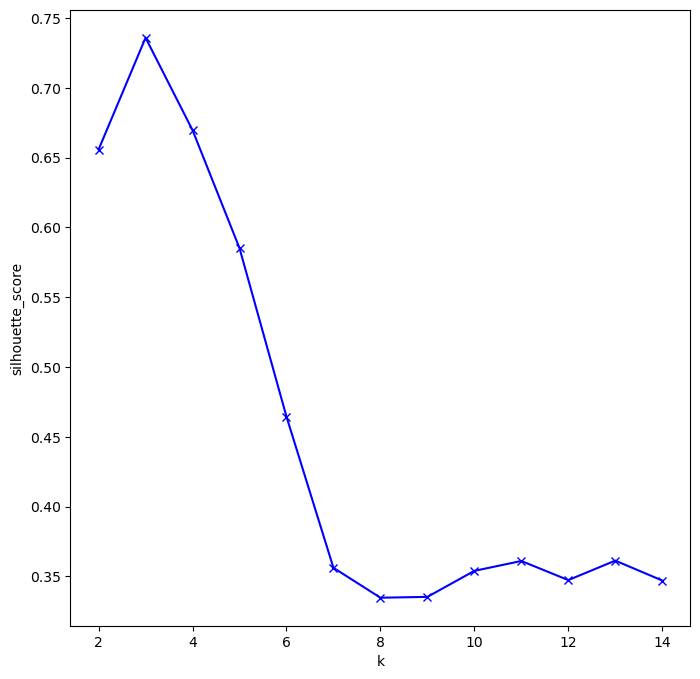

In [ ]:
silhouette_scores = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(X)
    y = km.predict(X)
    silhouette_scores.append(silhouette_score(X,y))
    
plt.figure(figsize=(8,8))
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('silhouette_score')
plt.show()

Evaluating k_means clusters

In [ ]:
plt.figure(figsize=(15,8))
km = KMeans(n_clusters=4)
visualizer = SilhouetteVisualizer(km, colors='yellowbrick')
visualizer.fit(X)